In [ ]:
%load_ext autoreload
%autoreload 2


In [2]:
import pandas as pd
pd.set_option('display.max_columns', None)
import numpy as np
import sys
import os
sys.path.append(os.path.join(os.getcwd(), '..', '..'))

from llm_good_enough import LLMGoodEnough


# PolitiFact S6 Analysis
**6-point scale dataset**

Data preprocessing is done in `preprocessing.ipynb`.


In [6]:
# Load cleaned S6 data
merged_s6_df = pd.read_csv("../data/merged_s6_cleaned.csv")
print(f"Loaded S6 data: {merged_s6_df.shape}")

# Identify human columns
HUMAN_COLS = [c for c in merged_s6_df.columns if c.startswith("human_#")]
LLM_COLS = ["GPT-4o mini"]

# Determine score boundaries from human ratings
unique_human_ratings = np.unique(merged_s6_df[HUMAN_COLS].values[~pd.isna(merged_s6_df[HUMAN_COLS].values)])
MIN_SCORE, MAX_SCORE = int(np.min(unique_human_ratings)), int(np.max(unique_human_ratings))
print(f"Human rating scale: {unique_human_ratings}")

merged_s6_df.head()

Loaded S6 data: (120, 32)
Human rating scale: [0. 1. 2. 3. 4. 5.]


,statement,GPT-4o mini,human_#1,human_#2,human_#3,human_#4,human_#5,human_#6,human_#7,human_#8,human_#9,human_#10,human_#11,human_#12,human_#13,human_#14,human_#15,human_#16,human_#17,human_#18,human_#19,human_#20,human_#21,human_#22,human_#23,human_#24,human_#25,human_#26,human_#27,human_#28,human_#29,human_#30
0,22 times Barack Obama said he did not have the...,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,6400 Ohioans lost manufacturing jobs in the m...,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,98 percent of small businesses make less than ...,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,A recent economic uptick appears to coincide w...,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,According to Wikipedia there are only five cou...,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## LLM vs Human Disagreement Barplot


In [ ]:
judge = LLMGoodEnough(
    df=merged_s6_df,
    human_cols=HUMAN_COLS,
    llm_cols=LLM_COLS,
    min_score=MIN_SCORE,
    max_score=MAX_SCORE,
    verbosity=1
)

judge.plot_judges_grid(
    save_path="../figures/svg/politifact_s6_barplot.svg"
)

## Monte Carlo Robustness Analysis


🎲 Random seed: 2814141365
✅ Found 30 valid human annotator columns.
✅ Keeping 36/120 rows with ≥2 human annotators.
✅ Added random judge baseline column: 'RANDOM_as_a_judge'


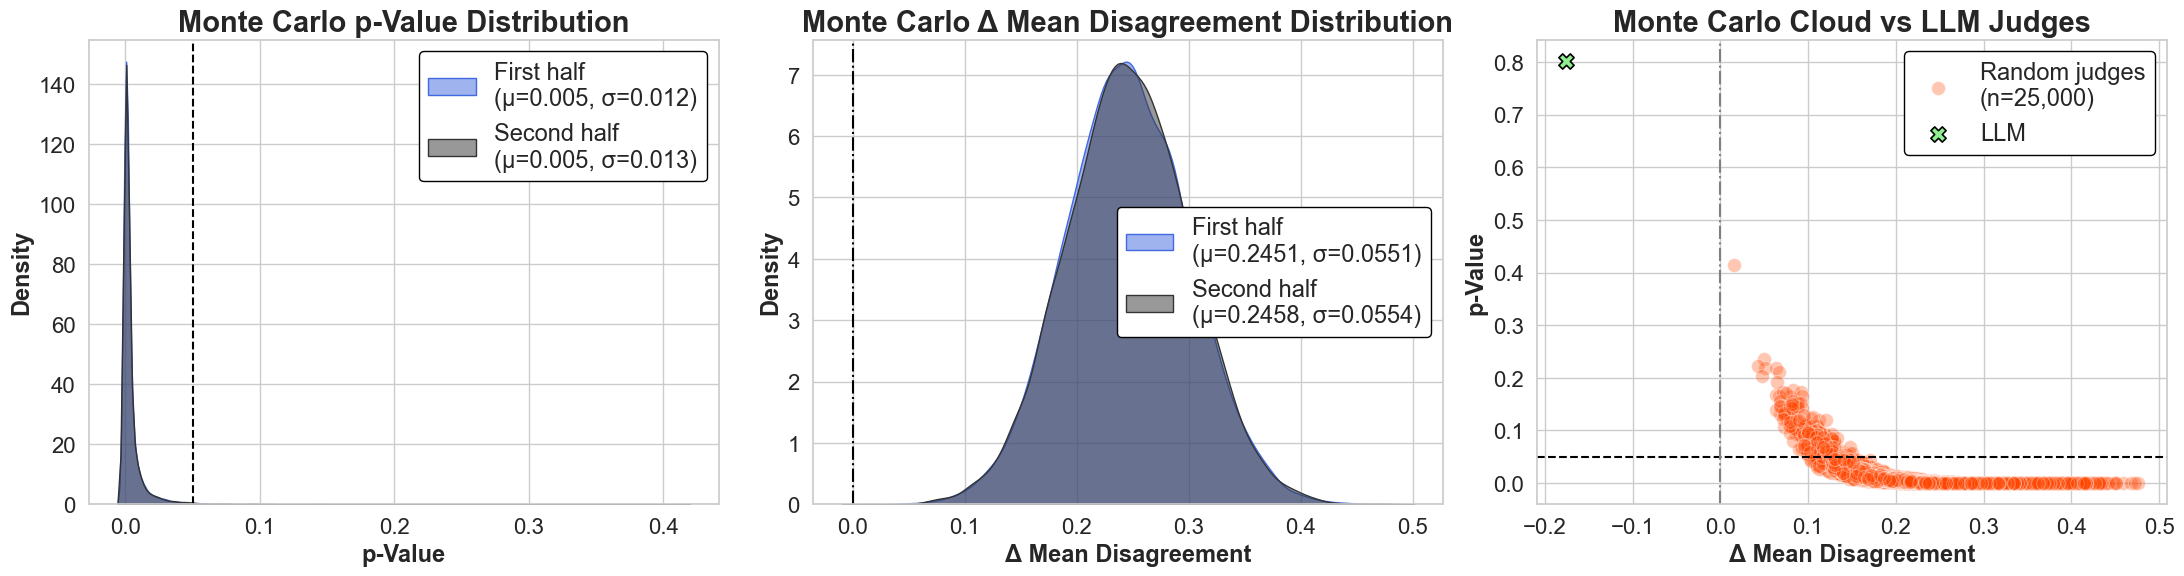

In [4]:
judge = LLMGoodEnough(
    df=merged_s6_df,
    human_cols=HUMAN_COLS,
    llm_cols=LLM_COLS,
    min_score=MIN_SCORE, 
    max_score=MAX_SCORE,
)

judge.plot_monte_carlo_robustness(
    llm_col="GPT-4o mini",
    save_path="../figures/svg/politifact_s6_monte_carlo_robustness.svg"
)

In [5]:
# P-value distribution analysis
counts = judge.count_pvalue_samples(iterations=25_000, threshold=0.05)

print("=" * 60)
print("P-value Distribution Analysis (S6)")
print("=" * 60)
print(f"Total Monte Carlo samples: {counts['total']:,}")
print(f"\nSamples with p-value > 0.05:  {counts['above']:,} ({counts['above_pct']:.2f}%)")
print(f"Samples with p-value ≤ 0.05:  {counts['below']:,} ({counts['below_pct']:.2f}%)")
print("=" * 60)


P-value Distribution Analysis (S6)
Total Monte Carlo samples: 25,000

Samples with p-value > 0.05:  330 (1.32%)
Samples with p-value ≤ 0.05:  24,670 (98.68%)


## Human Stability Analysis


In [ ]:
judge.plot_human_stability_analysis(
    convergence_threshold=0.000005,
    min_iterations=20_000,
    max_iterations=500_000,
    save_path="../figures/svg/politifact_s6_human_stability.svg",
    parallel=True,
)


In [ ]:
judge.plot_human_stability_analysis(
    percentages=[50, 100, 150, 200, 250, 300, 350, 400, 450, 500],
    convergence_threshold=0.000005,
    min_iterations=20_000,
    max_iterations=500_000,
    save_path="../figures/svg/politifact_s6_human_stability_100plus.svg",
    parallel=True,
)
